In [52]:
import numpy as np
import matplotlib.pyplot as plt
import simulate_data_script as sim
from importlib import reload 
reload(sim)

n = 3000
d = 500
k = 25
corr = 0.7

pi0 = 0.05
snr = 1

rng = np.random.default_rng(42)

X = sim.X_design(n, d, "corr_blocks", k = k, corr = corr, intercept=True, rng=rng)

n, d_total = X.shape 

beta, noise_var = sim.beta_sparse(d, X, pi0, snr, rng=rng)
beta = np.concatenate([[0], beta])
beta_blocks = np.concatenate([[0], 1 + np.arange(d) // k]) 
    
y_latent, l, u = sim.y_tobit(X, beta, 20, 80, noise_var, rng)

y = np.clip(y_latent, l, u)

true_pi0 =  (beta != 0).mean()
true_tau2 = beta[beta != 0].var()
print(f"True pi0 = {true_pi0:.2f}, true tau2 = {true_tau2:.3f}")

True pi0 = 0.05, true tau2 = 0.018


# $\tau^2$ sensitivity tests

In [53]:
def get_tau2_colors(tau2_grid, true_tau2):
    log_grid = np.log10(tau2_grid)
    log_true = np.log10(true_tau2)
    diff = log_grid - log_true 

    max_abs_diff = np.max(np.abs(diff))
    if max_abs_diff == 0:
        max_abs_diff = 1 

    colors = []
    for d in diff:
        t = np.abs(d) / max_abs_diff
        if d < 0:
            r = t
            g = 1.0
            b = 0.0
        elif d > 0:
            r = 0.0
            g = 1.0 - t
            b = t
        else:
            r, g, b = 0.0, 1.0, 0.0

        colors.append((r, g, b))

    return colors

MFVI (em_warmup): 0it [00:00, ?it/s]

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping


MFVI (em_warmup): 0it [00:00, ?it/s]

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

...

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping


MFVI (em_warmup): 0it [00:00, ?it/s]

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping


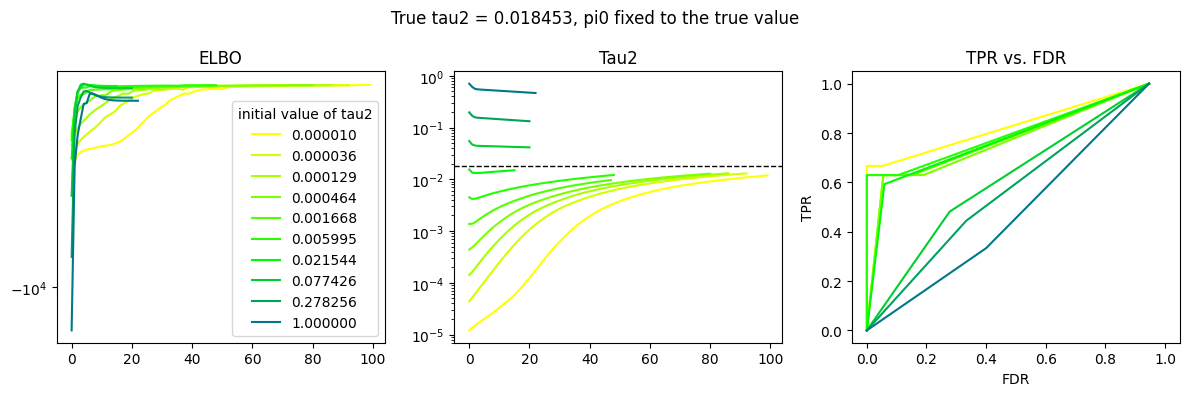

In [80]:
import matplotlib.pyplot as plt
import mfvi_blocks_script
reload(mfvi_blocks_script)
from mfvi_blocks_script import SparseTobitStructuredVI


tau2_grid = np.logspace(-5, 0, 10)  
colors = get_tau2_colors(tau2_grid, true_tau2)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].set_title("ELBO")
axes[1].set_title("Tau2")
axes[2].set_title("TPR vs. FDR")

axes[0].set_yscale('symlog', linthresh=1e-5)
axes[1].axhline(y=true_tau2, color='black', linestyle='--', linewidth=1, label='true_tau2')
axes[1].set_yscale('log')

axes[2].set_xlabel("FDR")
axes[2].set_ylabel("TPR")
axes[2].set_xlim(-0.05, 1.05)
axes[2].set_ylim(-0.05, 1.05)

# thresholds swept over rho to trace out the full TPR/FDR curve
thresholds = np.linspace(0, 1, 200)


for i, tau2 in enumerate(tau2_grid):

    model = SparseTobitStructuredVI(
        X, y,
        tau2=tau2,
        pi0=true_pi0,
        seed=22,
    )

    model.fit(
        n_iter=1000,
        em_tau2=True,
        em_pi0=False,
        em_warmup=0,
        gamma_batch_size=1,
        damping=0.3
    )

    sig_true = (beta != 0)
    rho = model.rho  # posterior inclusion probabilities

    tpr_curve = np.zeros_like(thresholds)
    fdr_curve = np.zeros_like(thresholds)

    for j, thresh in enumerate(thresholds):
        sig_pred = rho >= thresh

        tp = np.sum(sig_pred & sig_true)
        fp = np.sum(sig_pred & ~sig_true)
        fn = np.sum(~sig_pred & sig_true)

        tpr_curve[j] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fdr_curve[j] = fp / (fp + tp) if (fp + tp) > 0 else 0.0

    axes[0].plot(model.elbo_history, color=colors[i], label=f"{tau2:.6f}")
    axes[1].plot(model.tau2_history, color=colors[i], label=f"{tau2:.6f}")
    axes[2].plot(fdr_curve, tpr_curve, color=colors[i], label=f"{tau2:.6f}")

axes[0].legend(title="initial value of tau2")
plt.suptitle(f"True tau2 = {true_tau2:.6f}, pi0 fixed to the true value")
plt.tight_layout()
plt.show()

MFVI (em_warmup): 0it [00:00, ?it/s]

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping


MFVI (em_warmup): 0it [00:00, ?it/s]

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

...

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping


MFVI (em_warmup): 0it [00:00, ?it/s]

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping


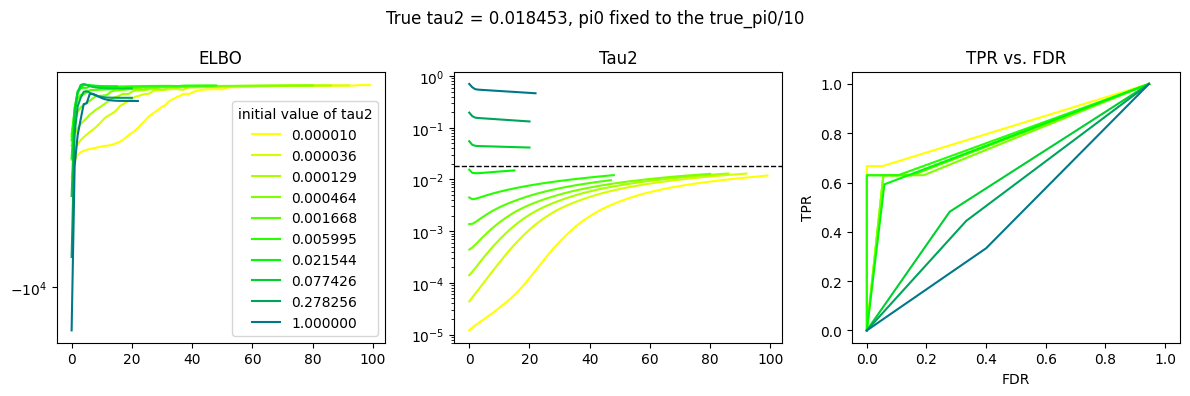

In [94]:
import matplotlib.pyplot as plt
import mfvi_blocks_script
reload(mfvi_blocks_script)
from mfvi_blocks_script import SparseTobitStructuredVI


tau2_grid = np.logspace(-5, 0, 10)  
colors = get_tau2_colors(tau2_grid, true_tau2)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].set_title("ELBO")
axes[1].set_title("Tau2")
axes[2].set_title("TPR vs. FDR")

axes[0].set_yscale('symlog', linthresh=1e-5)
axes[1].axhline(y=true_tau2, color='black', linestyle='--', linewidth=1, label='true_tau2')
axes[1].set_yscale('log')

axes[2].set_xlabel("FDR")
axes[2].set_ylabel("TPR")
axes[2].set_xlim(-0.05, 1.05)
axes[2].set_ylim(-0.05, 1.05)

# thresholds swept over rho to trace out the full TPR/FDR curve
thresholds = np.linspace(0, 1, 200)


for i, tau2 in enumerate(tau2_grid):

    model = SparseTobitStructuredVI(
        X, y,
        tau2=tau2,
        pi0=true_pi0,
        seed=22,
    )

    model.fit(
        n_iter=1000,
        em_tau2=True,
        em_pi0=False,
        em_warmup=0,
        gamma_batch_size=1,
        damping=0.3
    )

    sig_true = (beta != 0)
    rho = model.rho  # posterior inclusion probabilities

    tpr_curve = np.zeros_like(thresholds)
    fdr_curve = np.zeros_like(thresholds)

    for j, thresh in enumerate(thresholds):
        sig_pred = rho >= thresh

        tp = np.sum(sig_pred & sig_true)
        fp = np.sum(sig_pred & ~sig_true)
        fn = np.sum(~sig_pred & sig_true)

        tpr_curve[j] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fdr_curve[j] = fp / (fp + tp) if (fp + tp) > 0 else 0.0

    axes[0].plot(model.elbo_history, color=colors[i], label=f"{tau2:.6f}")
    axes[1].plot(model.tau2_history, color=colors[i], label=f"{tau2:.6f}")
    axes[2].plot(fdr_curve, tpr_curve, color=colors[i], label=f"{tau2:.6f}")

axes[0].legend(title="initial value of tau2")
plt.suptitle(f"True tau2 = {true_tau2:.6f}, pi0 fixed to the true_pi0/10")
plt.tight_layout()
plt.show()

MFVI (em_warmup): 0it [00:00, ?it/s]

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping


MFVI (em_warmup): 0it [00:00, ?it/s]

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

...

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping


MFVI (em_warmup): 0it [00:00, ?it/s]

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping


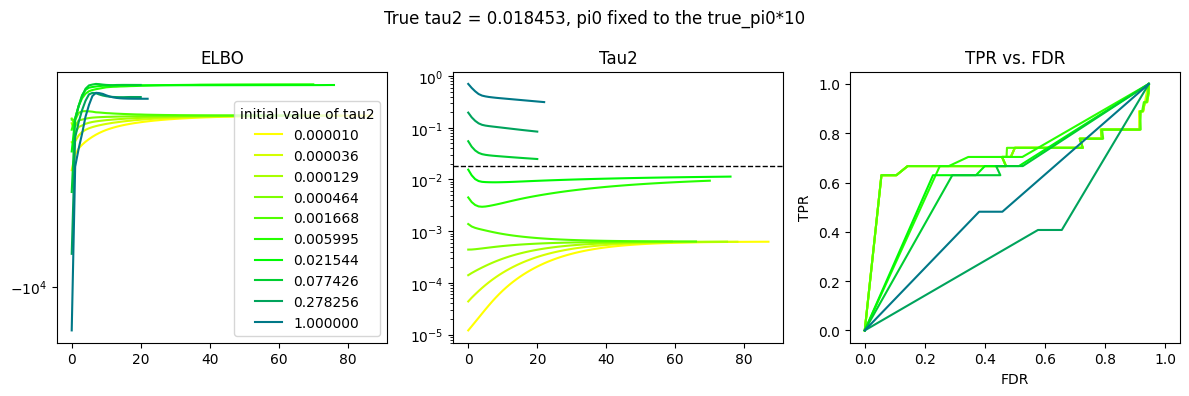

In [83]:
import matplotlib.pyplot as plt
import mfvi_blocks_script
reload(mfvi_blocks_script)
from mfvi_blocks_script import SparseTobitStructuredVI


tau2_grid = np.logspace(-5, 0, 10)  
colors = get_tau2_colors(tau2_grid, true_tau2)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].set_title("ELBO")
axes[1].set_title("Tau2")
axes[2].set_title("TPR vs. FDR")

axes[0].set_yscale('symlog', linthresh=1e-5)
axes[1].axhline(y=true_tau2, color='black', linestyle='--', linewidth=1, label='true_tau2')
axes[1].set_yscale('log')

axes[2].set_xlabel("FDR")
axes[2].set_ylabel("TPR")
axes[2].set_xlim(-0.05, 1.05)
axes[2].set_ylim(-0.05, 1.05)

# thresholds swept over rho to trace out the full TPR/FDR curve
thresholds = np.linspace(0, 1, 200)


for i, tau2 in enumerate(tau2_grid):

    model = SparseTobitStructuredVI(
        X, y,
        tau2=tau2,
        pi0=true_pi0*10,
        seed=22,
    )

    model.fit(
        n_iter=1000,
        em_tau2=True,
        em_pi0=False,
        em_warmup=0,
        gamma_batch_size=1,
        damping=0.3
    )

    sig_true = (beta != 0)
    rho = model.rho  # posterior inclusion probabilities

    tpr_curve = np.zeros_like(thresholds)
    fdr_curve = np.zeros_like(thresholds)

    for j, thresh in enumerate(thresholds):
        sig_pred = rho >= thresh

        tp = np.sum(sig_pred & sig_true)
        fp = np.sum(sig_pred & ~sig_true)
        fn = np.sum(~sig_pred & sig_true)

        tpr_curve[j] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fdr_curve[j] = fp / (fp + tp) if (fp + tp) > 0 else 0.0

    axes[0].plot(model.elbo_history, color=colors[i], label=f"{tau2:.6f}")
    axes[1].plot(model.tau2_history, color=colors[i], label=f"{tau2:.6f}")
    axes[2].plot(fdr_curve, tpr_curve, color=colors[i], label=f"{tau2:.6f}")

axes[0].legend(title="initial value of tau2")
plt.suptitle(f"True tau2 = {true_tau2:.6f}, pi0 fixed to the true_pi0*10")
plt.tight_layout()
plt.show()

MFVI (em_warmup): 0it [00:00, ?it/s]

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping


MFVI (em_warmup): 0it [00:00, ?it/s]

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

...

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping


MFVI (em_warmup): 0it [00:00, ?it/s]

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping


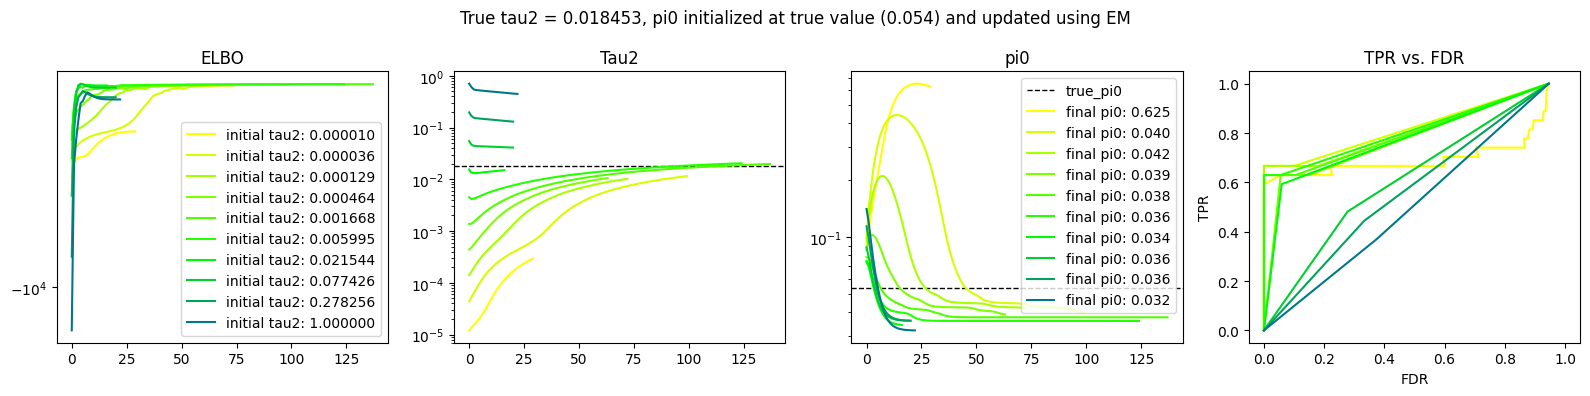

In [78]:
import matplotlib.pyplot as plt
import mfvi_blocks_script
reload(mfvi_blocks_script)
from mfvi_blocks_script import SparseTobitStructuredVI


tau2_grid = np.logspace(-5, 0, 10)  
colors = get_tau2_colors(tau2_grid, true_tau2)


fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].set_title("ELBO")
axes[1].set_title("Tau2")
axes[2].set_title("pi0")
axes[3].set_title("TPR vs. FDR")

axes[0].set_yscale('symlog', linthresh=1e-5)
axes[1].axhline(y=true_tau2, color='black', linestyle='--', linewidth=1, label='true_tau2')
axes[1].set_yscale('log')
axes[2].axhline(y=true_pi0, color='black', linestyle='--', linewidth=1, label='true_pi0')
axes[2].set_yscale('log')

axes[3].set_xlabel("FDR")
axes[3].set_ylabel("TPR")
axes[3].set_xlim(-0.05, 1.05)
axes[3].set_ylim(-0.05, 1.05)

# thresholds swept over rho to trace out the full TPR/FDR curve
thresholds = np.linspace(0, 1, 200)


for i, tau2 in enumerate(tau2_grid):

    model = SparseTobitStructuredVI(
        X, y,
        tau2=tau2,
        pi0=true_pi0,
        seed=22,
    )

    model.fit(
        n_iter=1000,
        em_tau2=True,
        em_pi0=True,
        em_warmup=0,
        gamma_batch_size=1,
        damping=0.3
    )

    sig_true = (beta != 0)
    rho = model.rho  # posterior inclusion probabilities

    tpr_curve = np.zeros_like(thresholds)
    fdr_curve = np.zeros_like(thresholds)

    for j, thresh in enumerate(thresholds):
        sig_pred = rho >= thresh

        tp = np.sum(sig_pred & sig_true)
        fp = np.sum(sig_pred & ~sig_true)
        fn = np.sum(~sig_pred & sig_true)

        tpr_curve[j] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fdr_curve[j] = fp / (fp + tp) if (fp + tp) > 0 else 0.0

    axes[0].plot(model.elbo_history, color=colors[i], label=f"initial tau2: {tau2:.6f}")
    axes[1].plot(model.tau2_history, color=colors[i], label=f"{tau2:.6f}")
    axes[2].plot(model.pi0_history, color=colors[i], label=f"final pi0: {model.pi0:.3f}")
    axes[3].plot(fdr_curve, tpr_curve, color=colors[i], label=f"{tau2:.6f}")

axes[0].legend()
axes[2].legend()
plt.suptitle(f"True tau2 = {true_tau2:.6f}, pi0 initialized at true value ({true_pi0:.3f}) and updated using EM")
plt.tight_layout()
plt.show()

In [70]:
(np.abs(beta) > 0.5 * np.sqrt(true_tau2)).mean()

0.03592814371257485

# $\pi_0$ sensitivity tests

MFVI (em_warmup): 0it [00:00, ?it/s]

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping


MFVI (em_warmup): 0it [00:00, ?it/s]

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

...

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping


MFVI (em_warmup): 0it [00:00, ?it/s]

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping


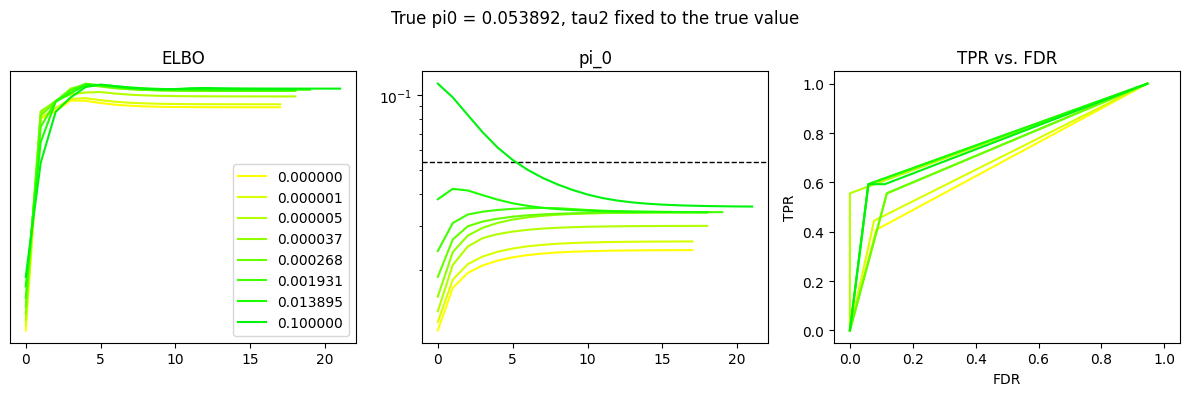

In [74]:
import matplotlib.pyplot as plt
import mfvi_blocks_script
reload(mfvi_blocks_script)
from mfvi_blocks_script import SparseTobitStructuredVI


pi0_grid = np.logspace(-7, -1, 8)  
colors = get_tau2_colors(pi0_grid, true_pi0)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].set_title("ELBO")
axes[1].set_title("pi_0")
axes[2].set_title("TPR vs. FDR")

axes[0].set_yscale('symlog', linthresh=1e-5)
axes[1].axhline(y=true_pi0, color='black', linestyle='--', linewidth=1, label='true_pi0')
axes[1].set_yscale('log')

axes[2].set_xlabel("FDR")
axes[2].set_ylabel("TPR")
axes[2].set_xlim(-0.05, 1.05)
axes[2].set_ylim(-0.05, 1.05)

# thresholds swept over rho to trace out the full TPR/FDR curve
thresholds = np.linspace(0, 1, 200)


for i, pi0 in enumerate(pi0_grid):

    model = SparseTobitStructuredVI(
        X, y,
        tau2=true_tau2,
        pi0= pi0,
        seed=22,
    )

    model.fit(
        n_iter=1000,
        em_tau2 = False,
        em_pi0 = True,
        em_warmup=0,
        gamma_batch_size=1,
        damping=0.3
    )

    sig_true = (beta != 0)
    rho = model.rho  # posterior inclusion probabilities

    tpr_curve = np.zeros_like(thresholds)
    fdr_curve = np.zeros_like(thresholds)

    for j, thresh in enumerate(thresholds):
        sig_pred = rho >= thresh

        tp = np.sum(sig_pred & sig_true)
        fp = np.sum(sig_pred & ~sig_true)
        fn = np.sum(~sig_pred & sig_true)

        tpr_curve[j] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fdr_curve[j] = fp / (fp + tp) if (fp + tp) > 0 else 0.0

    axes[0].plot(model.elbo_history, color=colors[i], label=f"{pi0:.6f}")
    axes[1].plot(model.pi0_history, color=colors[i], label=f"{pi0:.6f}")
    axes[2].plot(fdr_curve, tpr_curve, color=colors[i], label=f"{pi0:.6f}")

axes[0].legend()
plt.suptitle(f"True pi0 = {true_pi0:.6f}, tau2 fixed to the true value")
plt.tight_layout()
plt.show()

MFVI (em_warmup): 0it [00:00, ?it/s]

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping


MFVI (em_warmup): 0it [00:00, ?it/s]

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

...

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping


MFVI (em_warmup): 0it [00:00, ?it/s]

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping


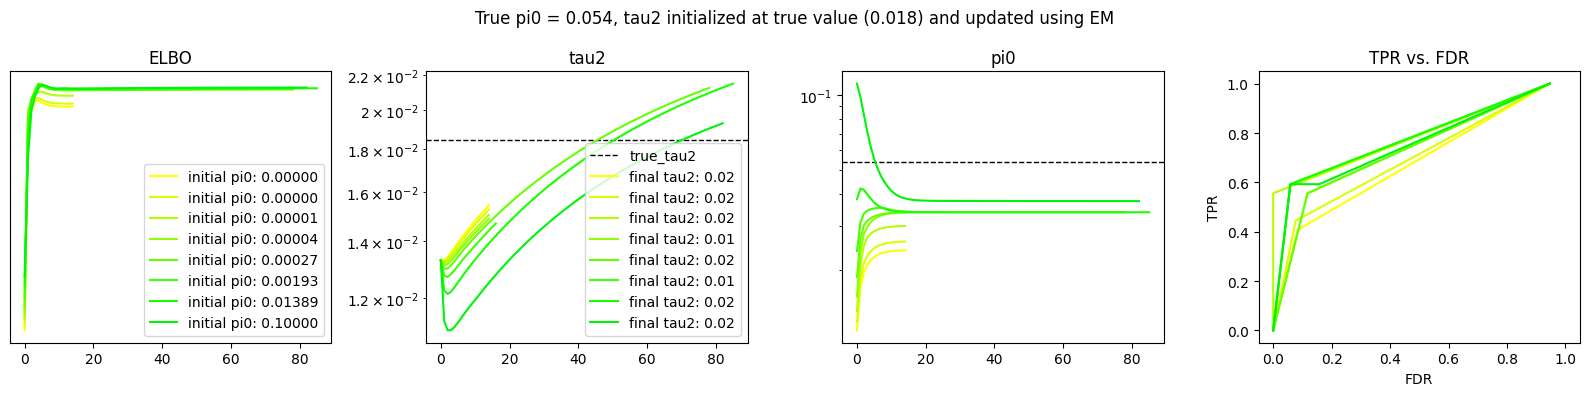

In [77]:
import matplotlib.pyplot as plt
import mfvi_blocks_script
reload(mfvi_blocks_script)
from mfvi_blocks_script import SparseTobitStructuredVI


pi0_grid = np.logspace(-7, -1, 8) 
colors = get_tau2_colors(pi0_grid, true_pi0)


fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].set_title("ELBO")
axes[1].set_title("tau2")
axes[2].set_title("pi0")
axes[3].set_title("TPR vs. FDR")

axes[0].set_yscale('symlog', linthresh=1e-5)
axes[1].axhline(y=true_tau2, color='black', linestyle='--', linewidth=1, label='true_tau2')
axes[1].set_yscale('log')
axes[2].axhline(y=true_pi0, color='black', linestyle='--', linewidth=1, label='true_pi0')
axes[2].set_yscale('log')

axes[3].set_xlabel("FDR")
axes[3].set_ylabel("TPR")
axes[3].set_xlim(-0.05, 1.05)
axes[3].set_ylim(-0.05, 1.05)

# thresholds swept over rho to trace out the full TPR/FDR curve
thresholds = np.linspace(0, 1, 200)


for i, pi0 in enumerate(pi0_grid):

    model = SparseTobitStructuredVI(
        X, y,
        tau2=true_tau2,
        pi0=pi0,
        seed=22,
    )

    model.fit(
        n_iter=1000,
        em_tau2=True,
        em_pi0=True,
        em_warmup=0,
        gamma_batch_size=1,
        damping=0.3
    )

    sig_true = (beta != 0)
    rho = model.rho  # posterior inclusion probabilities

    tpr_curve = np.zeros_like(thresholds)
    fdr_curve = np.zeros_like(thresholds)

    for j, thresh in enumerate(thresholds):
        sig_pred = rho >= thresh

        tp = np.sum(sig_pred & sig_true)
        fp = np.sum(sig_pred & ~sig_true)
        fn = np.sum(~sig_pred & sig_true)

        tpr_curve[j] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fdr_curve[j] = fp / (fp + tp) if (fp + tp) > 0 else 0.0

    axes[0].plot(model.elbo_history, color=colors[i], label=f"initial pi0: {pi0:.5f}")
    axes[1].plot(model.tau2_history, color=colors[i], label=f"final tau2: {model.tau2:.2f}")
    axes[2].plot(model.pi0_history, color=colors[i], label=f"{pi0:.6f}")
    axes[3].plot(fdr_curve, tpr_curve, color=colors[i], label=f"{pi0:.6f}")

axes[0].legend()
axes[1].legend()
plt.suptitle(f"True pi0 = {true_pi0:.3f}, tau2 initialized at true value ({true_tau2:.3f}) and updated using EM")
plt.tight_layout()
plt.show()

/localhome/mpieczar/tmp/ipykernel_2246506/1305824229.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmaps = [cm.get_cmap('Reds'), cm.get_cmap('Greens'), cm.get_cmap('Blues')]


MFVI (em_warmup): 0it [00:00, ?it/s]

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping


MFVI (em_warmup): 0it [00:00, ?it/s]

...

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping


MFVI (em_warmup): 0it [00:00, ?it/s]

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping


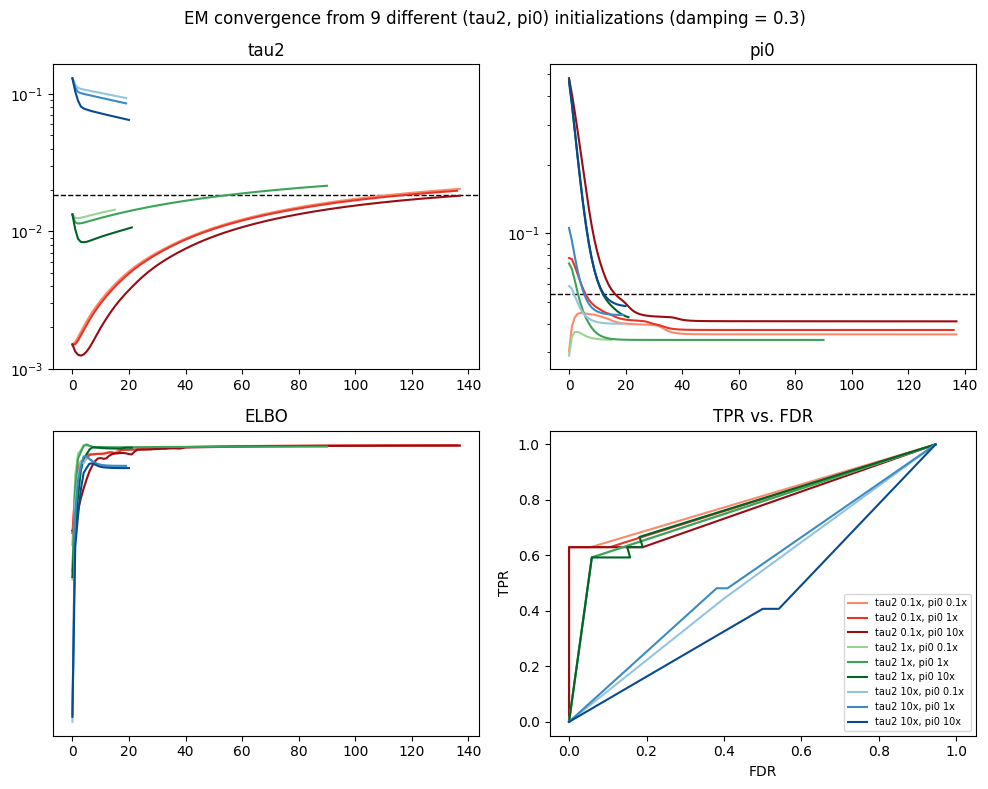

In [91]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import mfvi_blocks_script
reload(mfvi_blocks_script)
from mfvi_blocks_script import SparseTobitStructuredVI


# 9 scenarios: (tau2_init, pi0_init) combinations, expressed as multiples of the true values
tau2_mults = [0.1, 1, 10]
pi0_mults = [0.1, 1, 10]

tau2_inits = [m * true_tau2 for m in tau2_mults]
pi0_inits = [m * true_pi0 for m in pi0_mults]

scenarios = [
    (t2, p0, tm, pm)
    for t2, tm in zip(tau2_inits, tau2_mults)
    for p0, pm in zip(pi0_inits, pi0_mults)
]

# color scheme: hue encodes tau2 multiplier, shade (light->dark) encodes pi0 multiplier
# so curves with the same tau2 init share a color family, and pi0 controls how dark it is
base_cmaps = [cm.get_cmap('Reds'), cm.get_cmap('Greens'), cm.get_cmap('Blues')]
shade_levels = [0.4, 0.65, 0.9]  # light -> dark, matched to pi0_mults order

colors = []
for i, (_, _, tm, pm) in enumerate(scenarios):
    tau2_idx = tau2_mults.index(tm)
    pi0_idx = pi0_mults.index(pm)
    colors.append(base_cmaps[tau2_idx](shade_levels[pi0_idx]))


def format_mult(m):
    """Format a multiplier as e.g. '0.1x', '1x', '10x'."""
    if float(m).is_integer():
        return f"{int(m)}x"
    return f"{m:g}x"


fig, axes = plt.subplots(2, 2, figsize=(10, 8))

ax_tau2 = axes[0, 0]
ax_pi0 = axes[0, 1]
ax_elbo = axes[1, 0]
ax_roc = axes[1, 1]

ax_tau2.set_title("tau2")
ax_pi0.set_title("pi0")
ax_elbo.set_title("ELBO")
ax_roc.set_title("TPR vs. FDR")

ax_tau2.axhline(y=true_tau2, color='black', linestyle='--', linewidth=1, label='true_tau2')
ax_tau2.set_yscale('log')
ax_pi0.axhline(y=true_pi0, color='black', linestyle='--', linewidth=1, label='true_pi0')
ax_pi0.set_yscale('log')
ax_elbo.set_yscale('symlog', linthresh=1e-5)

ax_roc.set_xlabel("FDR")
ax_roc.set_ylabel("TPR")
ax_roc.set_xlim(-0.05, 1.05)
ax_roc.set_ylim(-0.05, 1.05)

# thresholds swept over rho to trace out the full TPR/FDR curve
thresholds = np.linspace(0, 1, 200)


for i, (tau2_init, pi0_init, tau2_mult, pi0_mult) in enumerate(scenarios):

    model = SparseTobitStructuredVI(
        X, y,
        tau2=tau2_init,
        pi0=pi0_init,
        seed=22,
    )

    model.fit(
        n_iter=1000,
        em_tau2=True,
        em_pi0=True,
        em_warmup=0,
        gamma_batch_size=1,
        damping=0.3
    )

    sig_true = (beta != 0)
    rho = model.rho  # posterior inclusion probabilities

    tpr_curve = np.zeros_like(thresholds)
    fdr_curve = np.zeros_like(thresholds)

    for j, thresh in enumerate(thresholds):
        sig_pred = rho >= thresh

        tp = np.sum(sig_pred & sig_true)
        fp = np.sum(sig_pred & ~sig_true)
        fn = np.sum(~sig_pred & sig_true)

        tpr_curve[j] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fdr_curve[j] = fp / (fp + tp) if (fp + tp) > 0 else 0.0

    label = f"tau2 {format_mult(tau2_mult)}, pi0 {format_mult(pi0_mult)}"

    ax_tau2.plot(model.tau2_history, color=colors[i], label=label)
    ax_pi0.plot(model.pi0_history, color=colors[i], label=label)
    ax_elbo.plot(model.elbo_history, color=colors[i], label=label)
    ax_roc.plot(fdr_curve, tpr_curve, color=colors[i], label=label)

ax_roc.legend(fontsize=7, loc='lower right')
plt.suptitle("EM convergence from 9 different (tau2, pi0) initializations (damping = 0.3)")
plt.tight_layout()
plt.show()

/localhome/mpieczar/tmp/ipykernel_2246506/3462645441.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmaps = [cm.get_cmap('Reds'), cm.get_cmap('Greens'), cm.get_cmap('Blues')]


MFVI (em_warmup): 0it [00:00, ?it/s]

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping


MFVI (em_warmup): 0it [00:00, ?it/s]

...

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping


MFVI (em_warmup): 0it [00:00, ?it/s]

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping


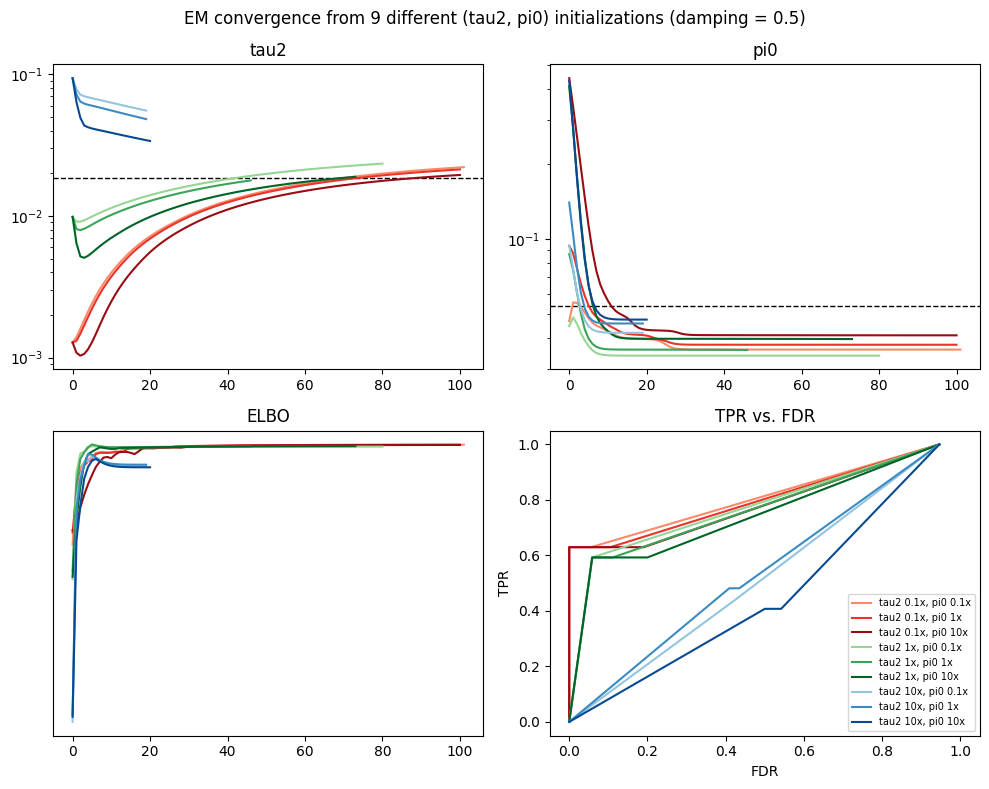

In [93]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import mfvi_blocks_script
reload(mfvi_blocks_script)
from mfvi_blocks_script import SparseTobitStructuredVI


# 9 scenarios: (tau2_init, pi0_init) combinations, expressed as multiples of the true values
tau2_mults = [0.1, 1, 10]
pi0_mults = [0.1, 1, 10]

tau2_inits = [m * true_tau2 for m in tau2_mults]
pi0_inits = [m * true_pi0 for m in pi0_mults]

scenarios = [
    (t2, p0, tm, pm)
    for t2, tm in zip(tau2_inits, tau2_mults)
    for p0, pm in zip(pi0_inits, pi0_mults)
]

# color scheme: hue encodes tau2 multiplier, shade (light->dark) encodes pi0 multiplier
# so curves with the same tau2 init share a color family, and pi0 controls how dark it is
base_cmaps = [cm.get_cmap('Reds'), cm.get_cmap('Greens'), cm.get_cmap('Blues')]
shade_levels = [0.4, 0.65, 0.9]  # light -> dark, matched to pi0_mults order

colors = []
for i, (_, _, tm, pm) in enumerate(scenarios):
    tau2_idx = tau2_mults.index(tm)
    pi0_idx = pi0_mults.index(pm)
    colors.append(base_cmaps[tau2_idx](shade_levels[pi0_idx]))


def format_mult(m):
    """Format a multiplier as e.g. '0.1x', '1x', '10x'."""
    if float(m).is_integer():
        return f"{int(m)}x"
    return f"{m:g}x"


fig, axes = plt.subplots(2, 2, figsize=(10, 8))

ax_tau2 = axes[0, 0]
ax_pi0 = axes[0, 1]
ax_elbo = axes[1, 0]
ax_roc = axes[1, 1]

ax_tau2.set_title("tau2")
ax_pi0.set_title("pi0")
ax_elbo.set_title("ELBO")
ax_roc.set_title("TPR vs. FDR")

ax_tau2.axhline(y=true_tau2, color='black', linestyle='--', linewidth=1, label='true_tau2')
ax_tau2.set_yscale('log')
ax_pi0.axhline(y=true_pi0, color='black', linestyle='--', linewidth=1, label='true_pi0')
ax_pi0.set_yscale('log')
ax_elbo.set_yscale('symlog', linthresh=1e-5)

ax_roc.set_xlabel("FDR")
ax_roc.set_ylabel("TPR")
ax_roc.set_xlim(-0.05, 1.05)
ax_roc.set_ylim(-0.05, 1.05)

# thresholds swept over rho to trace out the full TPR/FDR curve
thresholds = np.linspace(0, 1, 200)


for i, (tau2_init, pi0_init, tau2_mult, pi0_mult) in enumerate(scenarios):

    model = SparseTobitStructuredVI(
        X, y,
        tau2=tau2_init,
        pi0=pi0_init,
        seed=22,
    )

    model.fit(
        n_iter=1000,
        em_tau2=True,
        em_pi0=True,
        em_warmup=0,
        gamma_batch_size=1,
        damping=0.5
    )

    sig_true = (beta != 0)
    rho = model.rho  # posterior inclusion probabilities

    tpr_curve = np.zeros_like(thresholds)
    fdr_curve = np.zeros_like(thresholds)

    for j, thresh in enumerate(thresholds):
        sig_pred = rho >= thresh

        tp = np.sum(sig_pred & sig_true)
        fp = np.sum(sig_pred & ~sig_true)
        fn = np.sum(~sig_pred & sig_true)

        tpr_curve[j] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fdr_curve[j] = fp / (fp + tp) if (fp + tp) > 0 else 0.0

    label = f"tau2 {format_mult(tau2_mult)}, pi0 {format_mult(pi0_mult)}"

    ax_tau2.plot(model.tau2_history, color=colors[i], label=label)
    ax_pi0.plot(model.pi0_history, color=colors[i], label=label)
    ax_elbo.plot(model.elbo_history, color=colors[i], label=label)
    ax_roc.plot(fdr_curve, tpr_curve, color=colors[i], label=label)

ax_roc.legend(fontsize=7, loc='lower right')
plt.suptitle("EM convergence from 9 different (tau2, pi0) initializations (damping = 0.5)")
plt.tight_layout()
plt.show()

/localhome/mpieczar/tmp/ipykernel_2246506/2210798691.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmaps = [cm.get_cmap('Reds'), cm.get_cmap('Greens'), cm.get_cmap('Blues')]


MFVI (em_warmup): 0it [00:00, ?it/s]

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping


MFVI (em_warmup): 0it [00:00, ?it/s]

...

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping


MFVI (em_warmup): 0it [00:00, ?it/s]

MFVI (EM):   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping


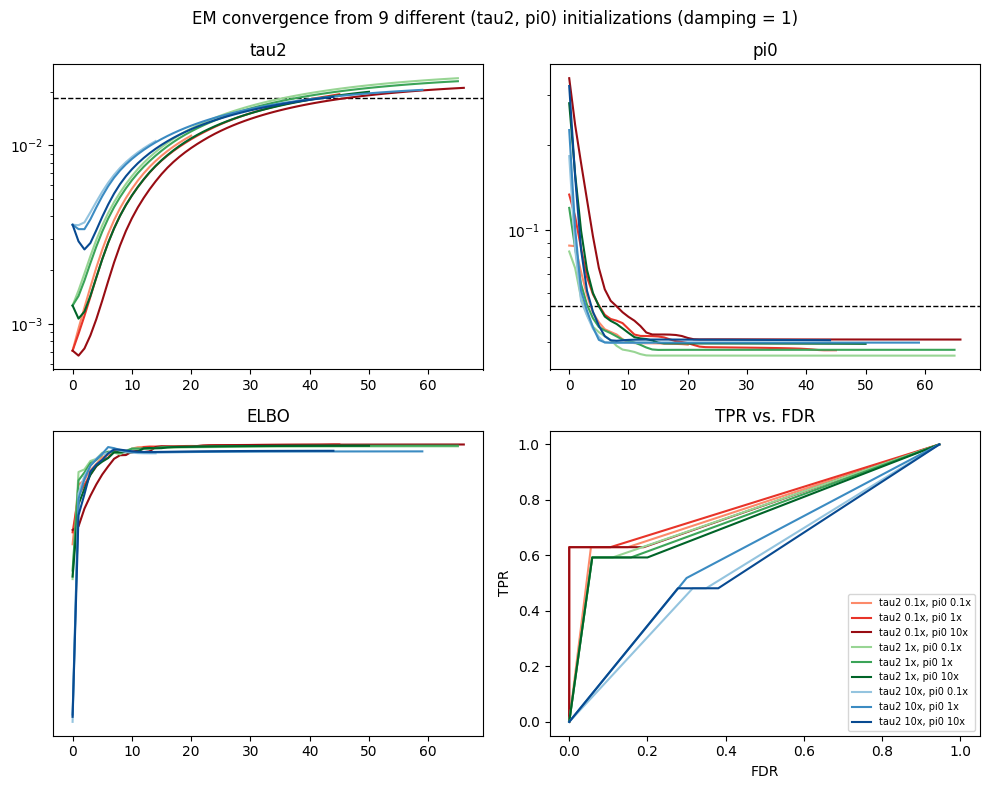

In [92]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import mfvi_blocks_script
reload(mfvi_blocks_script)
from mfvi_blocks_script import SparseTobitStructuredVI


# 9 scenarios: (tau2_init, pi0_init) combinations, expressed as multiples of the true values
tau2_mults = [0.1, 1, 10]
pi0_mults = [0.1, 1, 10]

tau2_inits = [m * true_tau2 for m in tau2_mults]
pi0_inits = [m * true_pi0 for m in pi0_mults]

scenarios = [
    (t2, p0, tm, pm)
    for t2, tm in zip(tau2_inits, tau2_mults)
    for p0, pm in zip(pi0_inits, pi0_mults)
]

# color scheme: hue encodes tau2 multiplier, shade (light->dark) encodes pi0 multiplier
# so curves with the same tau2 init share a color family, and pi0 controls how dark it is
base_cmaps = [cm.get_cmap('Reds'), cm.get_cmap('Greens'), cm.get_cmap('Blues')]
shade_levels = [0.4, 0.65, 0.9]  # light -> dark, matched to pi0_mults order

colors = []
for i, (_, _, tm, pm) in enumerate(scenarios):
    tau2_idx = tau2_mults.index(tm)
    pi0_idx = pi0_mults.index(pm)
    colors.append(base_cmaps[tau2_idx](shade_levels[pi0_idx]))


def format_mult(m):
    """Format a multiplier as e.g. '0.1x', '1x', '10x'."""
    if float(m).is_integer():
        return f"{int(m)}x"
    return f"{m:g}x"


fig, axes = plt.subplots(2, 2, figsize=(10, 8))

ax_tau2 = axes[0, 0]
ax_pi0 = axes[0, 1]
ax_elbo = axes[1, 0]
ax_roc = axes[1, 1]

ax_tau2.set_title("tau2")
ax_pi0.set_title("pi0")
ax_elbo.set_title("ELBO")
ax_roc.set_title("TPR vs. FDR")

ax_tau2.axhline(y=true_tau2, color='black', linestyle='--', linewidth=1, label='true_tau2')
ax_tau2.set_yscale('log')
ax_pi0.axhline(y=true_pi0, color='black', linestyle='--', linewidth=1, label='true_pi0')
ax_pi0.set_yscale('log')
ax_elbo.set_yscale('symlog', linthresh=1e-5)

ax_roc.set_xlabel("FDR")
ax_roc.set_ylabel("TPR")
ax_roc.set_xlim(-0.05, 1.05)
ax_roc.set_ylim(-0.05, 1.05)

# thresholds swept over rho to trace out the full TPR/FDR curve
thresholds = np.linspace(0, 1, 200)


for i, (tau2_init, pi0_init, tau2_mult, pi0_mult) in enumerate(scenarios):

    model = SparseTobitStructuredVI(
        X, y,
        tau2=tau2_init,
        pi0=pi0_init,
        seed=22,
    )

    model.fit(
        n_iter=1000,
        em_tau2=True,
        em_pi0=True,
        em_warmup=0,
        gamma_batch_size=1,
        damping=1
    )

    sig_true = (beta != 0)
    rho = model.rho  # posterior inclusion probabilities

    tpr_curve = np.zeros_like(thresholds)
    fdr_curve = np.zeros_like(thresholds)

    for j, thresh in enumerate(thresholds):
        sig_pred = rho >= thresh

        tp = np.sum(sig_pred & sig_true)
        fp = np.sum(sig_pred & ~sig_true)
        fn = np.sum(~sig_pred & sig_true)

        tpr_curve[j] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fdr_curve[j] = fp / (fp + tp) if (fp + tp) > 0 else 0.0

    label = f"tau2 {format_mult(tau2_mult)}, pi0 {format_mult(pi0_mult)}"

    ax_tau2.plot(model.tau2_history, color=colors[i], label=label)
    ax_pi0.plot(model.pi0_history, color=colors[i], label=label)
    ax_elbo.plot(model.elbo_history, color=colors[i], label=label)
    ax_roc.plot(fdr_curve, tpr_curve, color=colors[i], label=label)

ax_roc.legend(fontsize=7, loc='lower right')
plt.suptitle("EM convergence from 9 different (tau2, pi0) initializations (damping = 1)")
plt.tight_layout()
plt.show()